In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

RANDOM_SEED = 9876

PROJECT_ROOT = Path('.')
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


In [2]:
central_path = DATA_DIR / 'Central2024P.csv'
test_path = DATA_DIR / 'Central2024testP.csv'


central = pd.read_csv(central_path)
central_test_external = pd.read_csv(test_path)

central.head()


,Price,Area,Age,Tenure,Purchaser,Region
0,1412345.0,678.13,7,Leasehold,HDB,Bishan
1,960000.0,484.38,7,Leasehold,Private,Bishan
2,2180000.0,1280.92,8,Leasehold,HDB,Bishan
3,2450000.0,1248.62,12,Leasehold,Private,Bishan
4,2300000.0,1367.03,8,Leasehold,Private,Bishan


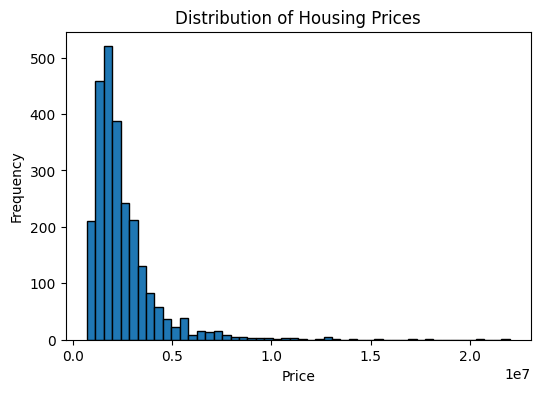

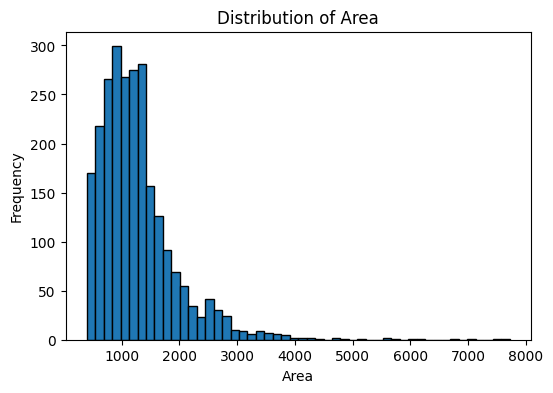

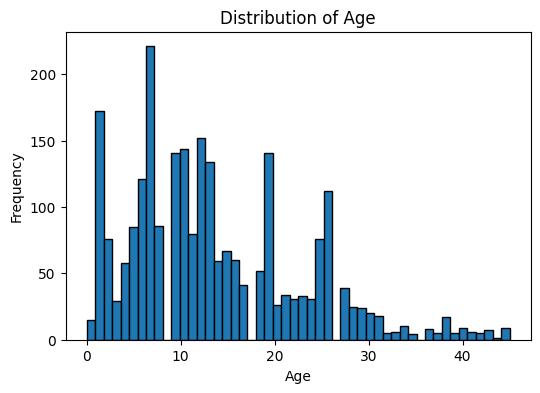

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(central['Price'], bins=50, edgecolor='black')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'price_hist.png', dpi=200)
plt.show()


plt.figure(figsize=(6,4))
plt.hist(central['Area'], bins=50, edgecolor='black')
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'area_hist.png', dpi=200)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(central['Age'], bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'age_hist.png', dpi=200)
plt.show()


# here we see that price and area are right skewed, will log transform both 

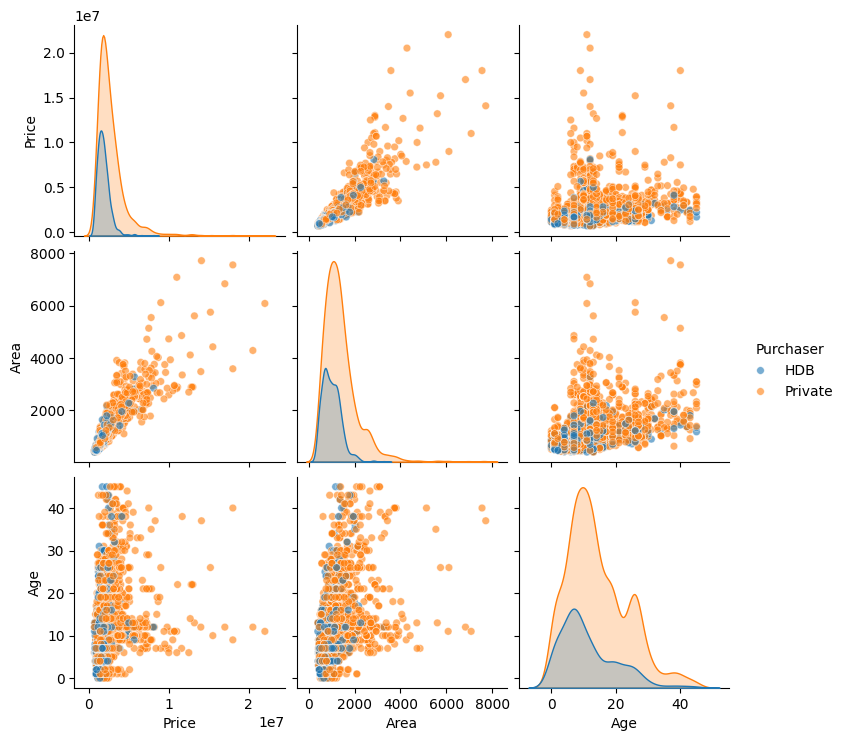

In [29]:
sns.pairplot(central
             , vars= ['Price', 'Area', 'Age']
             , hue='Purchaser'
             , plot_kws= {'alpha':0.6, 's': 30 }) 
plt.savefig(FIGURES_DIR / 'pairplot_purchaser.png', dpi=200)

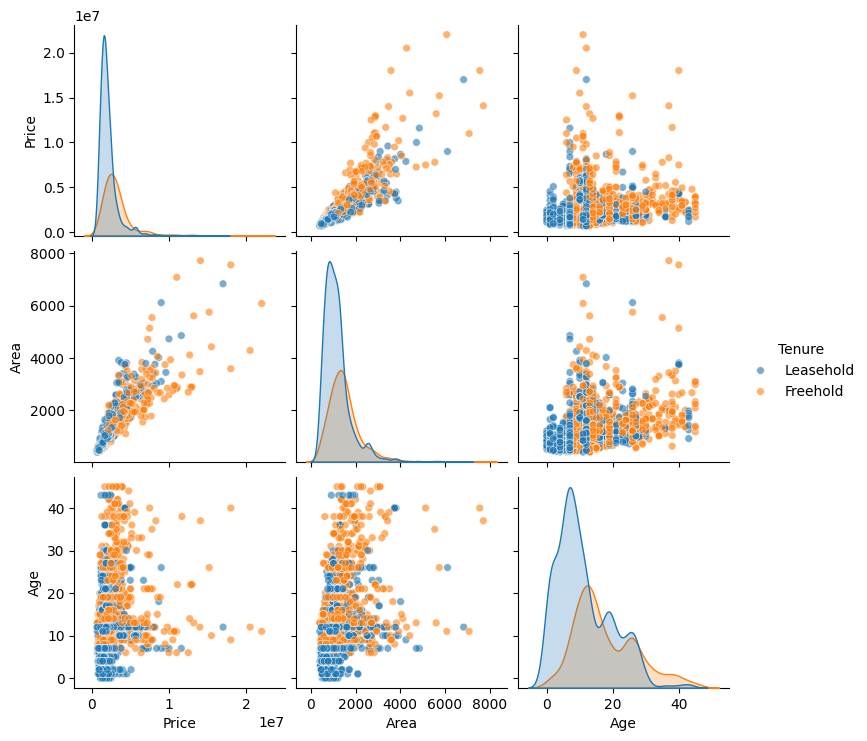

In [30]:
sns.pairplot(central
             , vars= ['Price', 'Area', 'Age']
             , hue='Tenure'
             , plot_kws= {'alpha':0.6, 's': 30 }) 
plt.savefig(FIGURES_DIR / 'pairplot_tenure.png', dpi=200)

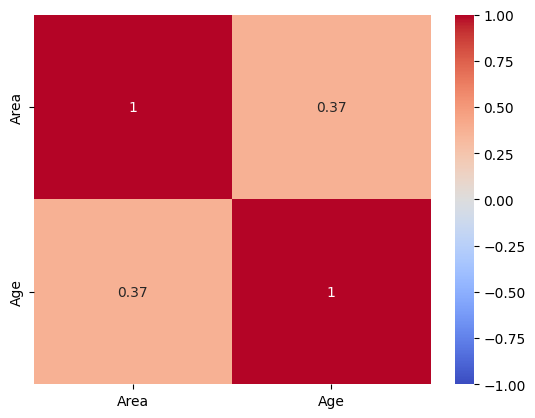

In [31]:
sns.heatmap(central[['Area', 'Age']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=200)

<Axes: xlabel='Price'>

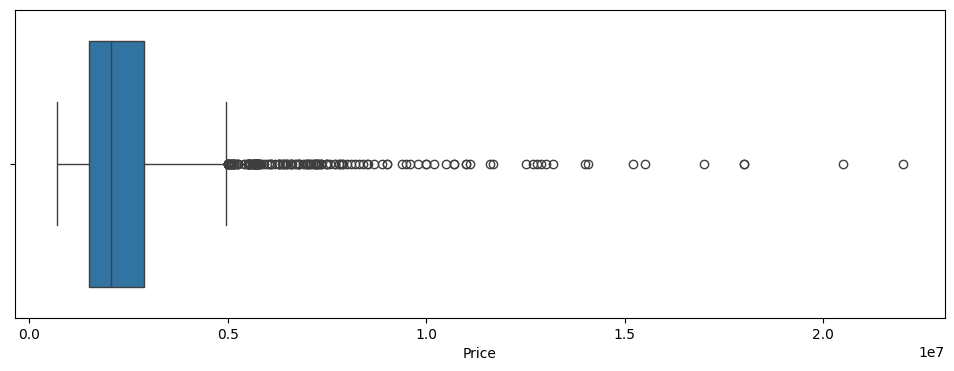

In [28]:
boxplot_data = central[['Price']]
plt.figure(figsize=(12, 4))
sns.boxplot(x=boxplot_data['Price'])

## Train/Test Splits and Preprocessing


In [5]:
central_train, central_test = train_test_split(
    central,
    test_size=0.15,
    random_state=RANDOM_SEED
)



central_train.shape, central_test.shape

((2125, 6), (375, 6))

In [6]:
X_train = central_train.drop(columns=['Price'])  
y_train = central_train['Price']
X_test = central_test.drop(columns=['Price'])
y_test = central_test['Price']

xgb_X_train = X_train.copy()
xgb_y_train = y_train.copy()
xgb_X_test = X_test.copy()
xgb_y_test = y_test.copy()

# plt.figure(figsize=(6, 4))
# plt.hist(central['Price'], bins=50, edgecolor='black')
# plt.title('Distribution of Housing Prices')
# plt.xlabel('Price')
# plt.ylabel('Frequency')
# plt.show()

## Polynomial degree selection (Area, Age) via 10-fold CV



3 6


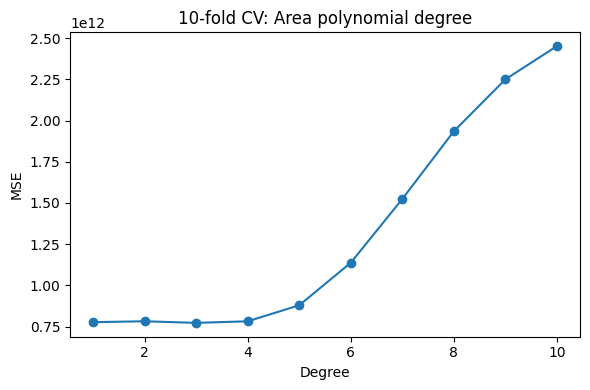

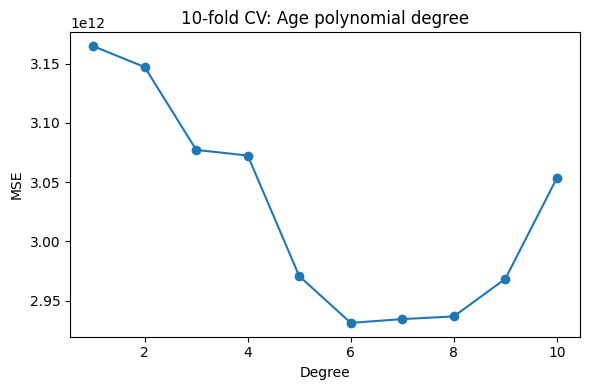

In [7]:
def poly_cv_mse(df, feature, target='Price', max_degree=10, k=10, random_state=RANDOM_SEED):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    mse_per_degree = []
    X = df[[feature]].values
    y = df[target].values

    for degree in range(1, max_degree + 1):
        fold_mse = []
        for train_idx, test_idx in kf.split(X):
            X_train = X[train_idx]
            X_test = X[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]

            # Create polynomial features manually
            X_train_poly = np.column_stack([X_train ** d for d in range(1, degree + 1)])
            X_test_poly = np.column_stack([X_test ** d for d in range(1, degree + 1)])

            model = LinearRegression()
            model.fit(X_train_poly, y_train)
            preds = model.predict(X_test_poly)
            fold_mse.append(mean_squared_error(y_test, preds))

        mse_per_degree.append(np.mean(fold_mse))

    return mse_per_degree

area_cv_mse = poly_cv_mse(central_train, 'Area')
age_cv_mse = poly_cv_mse(central_train, 'Age')

best_degree_area = int(np.argmin(area_cv_mse) + 1)
best_degree_age = int(np.argmin(age_cv_mse) + 1)

print(best_degree_area, best_degree_age)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), area_cv_mse, marker='o')
plt.title('10-fold CV: Area polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_area.png', dpi=200)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), age_cv_mse, marker='o')
plt.title('10-fold CV: Age polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_age.png', dpi=200)
plt.show()

## Feature Engineering Pipeline

Includes:
- Polynomial terms for Area/Age (CV-selected)
- Interactions terms



In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, degree_area=1, degree_age=1):    
        self.degree_area = degree_area
        self.degree_age = degree_age

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        df['Area'] = np.log1p(df['Area'])

        # Polynomial terms
        for d in range(2, self.degree_area + 1):
            df[f'Area_^_{d}'] = df['Area'] ** d
        for d in range(2, self.degree_age + 1):
            df[f'Age_^_{d}'] = df['Age'] ** d

        
        df['area_per_age'] = df['Area'] / (df['Age'] + 1)

        region_dummies = pd.get_dummies(df['Region'], prefix='Region')
        for col in region_dummies.columns:
            df[f'Area_x_{col}'] = df['Area'] * region_dummies[col]

        tenure_dummies = pd.get_dummies(df['Tenure'], prefix='Tenure')
        for col in tenure_dummies.columns:
            df[f'Area_x_{col}'] = df['Area'] * tenure_dummies[col]

        

        return df   

feature_engineer = FeatureEngineer(degree_area=best_degree_area, degree_age= best_degree_age)
sample_fe = feature_engineer.fit_transform(X_train)
numeric_features = sample_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
                    ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)


## Model Training (Lasso, Ridge, ElasticNet, XGBoost)

In [ ]:
lasso = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', LassoCV(cv=5, random_state=RANDOM_SEED))
])

ridge = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

elastic = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=RANDOM_SEED))
])



models = {
    'LassoCV': lasso,
    'RidgeCV': ridge,
    'ElasticNetCV': elastic
}
y_train_log = np.log1p(y_train)
for name, model in models.items():
    model.fit(X_train, y_train_log)

In [10]:
class XGBPrep(BaseEstimator, TransformerMixin):
    def __init__(self, degree_area=1, degree_age=1):    
        self.degree_area = degree_area
        self.degree_age = degree_age
        

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        
        for col in ["Tenure", "Region", "Purchaser"]:
            if col in df.columns:
                df[col] = df[col].astype("category")

        df['area_per_age'] = df['Area'] / (df['Age'] + 1)
        df['age_bucket'] = pd.cut(df['Age'], bins=[-1, 10, 20, 30, 40, 50, np.inf], labels=False)

        return df

xgb = Pipeline([
    ("prep", XGBPrep()),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        enable_categorical=True,
        tree_method="hist" 
    ))
])




# Stepwise XGBoost hyperparameter tuning (GridSearchCV per group)
# sequential group tuning (max_depth/min_child_weight) ->
# (subsample/colsample_bytree) -> (learning_rate/n_estimators)

stepwise_cv_results = {}
stepwise_best_params = {}

base_fixed_params = {
    "model__learning_rate": 0.1,
    "model__n_estimators": 2000
}

xgb_working = xgb.set_params(**base_fixed_params)

group_1_grid = {
    "model__max_depth": [ 3, 4,5,6],
    "model__min_child_weight": [1, 3, 5,7, 10],
}

group_1_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_1_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_1_search.fit(X_train, y_train)

stepwise_cv_results["group_1"] = pd.DataFrame(group_1_search.cv_results_)
stepwise_best_params.update(group_1_search.best_params_)

xgb_working = group_1_search.best_estimator_


# (GROUP 1 fixed at best; GROUP 3 fixed at initial values)
xgb_working = xgb_working.set_params(
    model__learning_rate=0.1,
    model__n_estimators=1000,
)

group_2_grid = {
    "model__subsample": [0.5, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.8, 1.0],
}

group_2_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_2_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_2_search.fit(X_train, y_train)

stepwise_cv_results["group_2"] = pd.DataFrame(group_2_search.cv_results_)
stepwise_best_params.update(group_2_search.best_params_)

xgb_working = group_2_search.best_estimator_


# (GROUP 1-2 fixed at best)

group_3_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [400, 600, 1000, 1500],
    "model__gamma" : [0, 0.1, 1, 2]
    
}

group_3_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_3_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_3_search.fit(X_train, y_train)

stepwise_cv_results["group_3"] = pd.DataFrame(group_3_search.cv_results_)
stepwise_best_params.update(group_3_search.best_params_)

best_xgb = group_3_search.best_estimator_

stepwise_best_params

{'model__max_depth': 5,
 'model__min_child_weight': 5,
 'model__colsample_bytree': 0.7,
 'model__subsample': 0.8,
 'model__gamma': 0,
 'model__learning_rate': 0.1,
 'model__n_estimators': 400}

## Validation performance comparison (primary metric: RMSE)

In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(name, model, X, y, is_logged=True):
    if is_logged:
        preds_log = model.predict(X)
        preds = np.expm1(preds_log)
    else:
        preds = model.predict(X)

    return {
        "Model": name,
        "RMSE": rmse(y, preds),
        "MAE": mean_absolute_error(y, preds),
        "R2": r2_score(y, preds),
        "MAPE": mape(y, preds),
    }

results = []



for name, model in models.items():
    results.append(evaluate_model(name, model, X_test, y_test))

results.append(evaluate_model('XGBoost', best_xgb, xgb_X_test, xgb_y_test, is_logged = False))

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,RMSE,MAE,R2,MAPE
3,XGBoost,348561.474353,194739.381833,0.946196,7.688686
1,RidgeCV,556074.415923,300440.152632,0.863062,10.196112
0,LassoCV,560129.991799,307701.899316,0.861057,10.542886
2,ElasticNetCV,560289.907451,307766.433764,0.860978,10.544641


## Fit best model on full data set

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = {
    'LassoCV': models['LassoCV'],
    'RidgeCV': models['RidgeCV'],
    'ElasticNetCV': models['ElasticNetCV'],
    'XGBoost': best_xgb
}[best_model_name]



full_train_set = central.drop(columns=['Price'])

best_model.fit(full_train_set, central['Price'])


## External test data (Central2024testP.csv)

In [13]:
X_external = central_test_external.drop(columns=['Price'])

y_external = central_test_external['Price']
external_metrics = evaluate_model(best_model_name, best_model, X_external, y_external, is_logged= False)

external_metrics 

{'Model': 'XGBoost',
 'RMSE': np.float64(887083.5781196238),
 'MAE': 291724.7825552826,
 'R2': 0.867859316767075,
 'MAPE': np.float64(8.428646683414632)}

## Diagnostics and plots

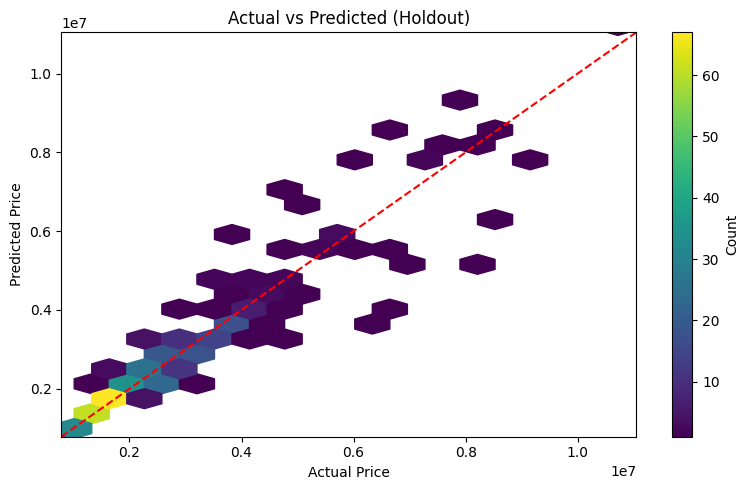

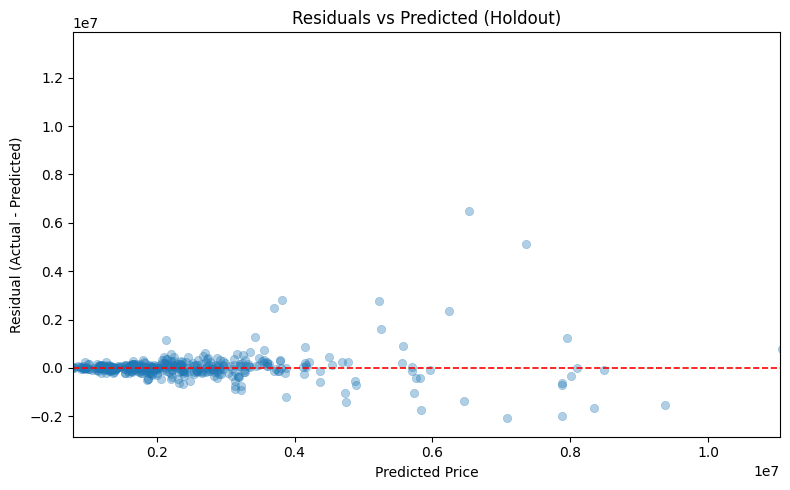

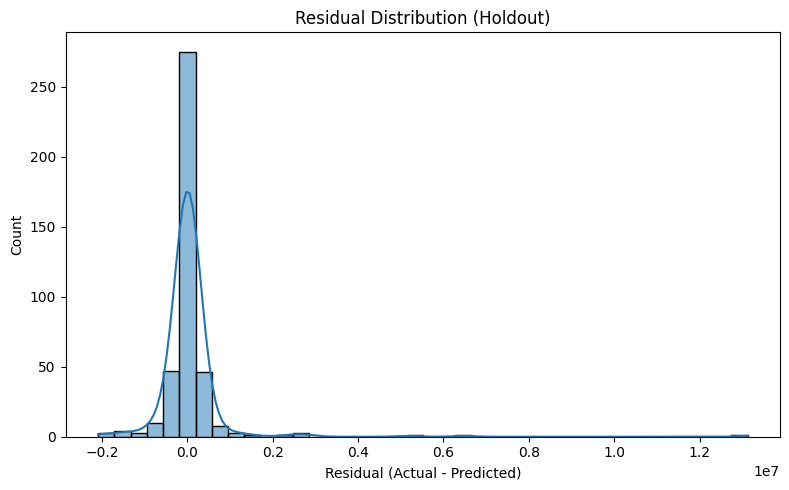

,y_true,y_pred,residual,abs_error,abs_pct_error
0,3000000.0,2882717.000,117283.000,117283.000,3.909433
1,1910000.0,1898600.375,11399.625,11399.625,0.596839
2,1380000.0,1392819.875,-12819.875,12819.875,0.928976
3,1025000.0,1152654.750,-127654.750,127654.750,12.454122
4,1170000.0,1171488.375,-1488.375,1488.375,0.127212


In [14]:
def plot_pred_vs_actual(
    *,
    y_true_log,
    y_pred_log,
    figures_dir,
    prefix,
    title_suffix="", ):
    y_true = np.asarray(y_true_log).reshape(-1)
    y_pred = np.asarray(y_pred_log).reshape(-1)

    pred_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    pred_df["abs_error"] = pred_df["residual"].abs()
    pred_df["abs_pct_error"] = (
        (pred_df["abs_error"] / pred_df["y_true"]) * 100.0
    )

    lo = float(np.nanpercentile(pred_df[["y_true", "y_pred"]].to_numpy(), 1))
    hi = float(np.nanpercentile(pred_df[["y_true", "y_pred"]].to_numpy(), 99))

    # Actual vs Predicted (hexbin)
    plt.figure(figsize=(8, 5))
    plt.hexbin(
        pred_df["y_true"],
        pred_df["y_pred"],
        gridsize=50,
        cmap="viridis",
        mincnt=1,
    )
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=1.5)
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.colorbar(label="Count")
    plt.title(f"Actual vs Predicted{title_suffix}")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_actual_vs_pred.png", dpi=220)
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="residual",
        alpha=0.35,
        edgecolor=None,
    )
    plt.axhline(0.0, color="red", linestyle="--", linewidth=1.2)
    plt.xlim(lo, hi)
    plt.title(f"Residuals vs Predicted{title_suffix}")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_residuals_vs_pred.png", dpi=200)
    plt.show()

    # Residual distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(pred_df["residual"], bins=40, kde=True)
    plt.title(f"Residual Distribution{title_suffix}")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_residual_hist.png", dpi=200)
    plt.show()

    return pred_df


pred_holdout_log = best_model.predict(X_external)

pred_df_holdout = plot_pred_vs_actual(
    y_true_log=y_external,
    y_pred_log=pred_holdout_log,
    figures_dir=FIGURES_DIR,
    prefix="holdout",
    title_suffix=" (Holdout)",
)

pred_df_holdout.head()

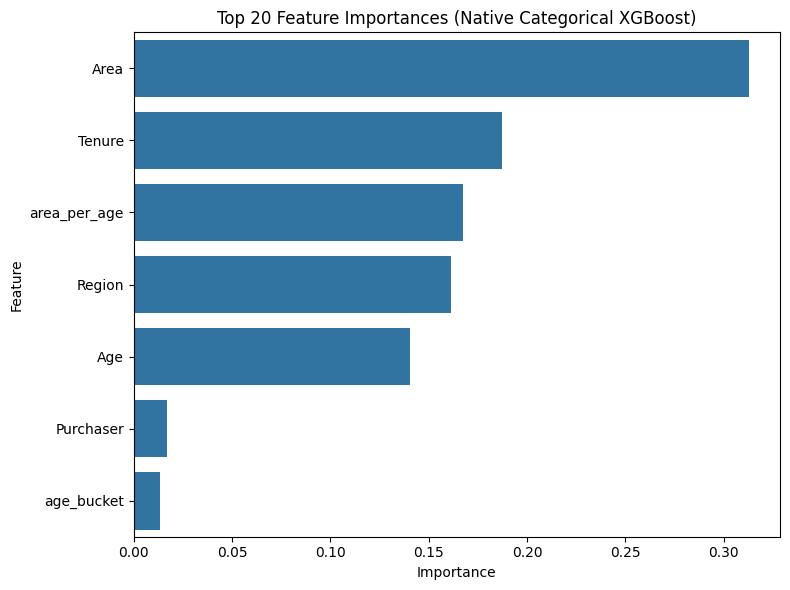

In [15]:
# XGBoost feature importance
if best_model_name == 'XGBoost':
    booster = best_model.named_steps['model']
    importance = booster.feature_importances_
    X_ref = X_train.copy()
    X_ref_prepped = best_xgb.named_steps["prep"].transform(X_ref)
    feature_names = X_ref_prepped.columns.tolist()

   
    fi = pd.DataFrame(
        {"feature": feature_names, "importance": importance}
    ).sort_values("importance", ascending=False)

    
    top_k = 20
    fi_top = fi.head(top_k)

   
    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_top, x="importance", y="feature")
    plt.title(f"Top {top_k} Feature Importances (Native Categorical XGBoost)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "xgb_native_feature_importance_top20.png", dpi=220)
    plt.show()

    fi_top

## Save artefacts

In [16]:
central_train.to_csv(PROCESSED_DIR / 'central_train.csv', index=False)
central_test.to_csv(PROCESSED_DIR / 'central_test.csv', index=False)

results_df.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
pd.DataFrame([external_metrics]).to_csv(PROCESSED_DIR / 'external_metrics.csv', index=False)
